# YOLOv12 Inference Throughput

Measures inference FPS and latency on a Jetson, parameterized over model variant, image size, compression backend, input source, and which pipeline stages are included in the timing. Centered on `model.predict()` — the same code path that runs in production. Accuracy is an opt-in sanity check, not the headline.

Design: see `throughput_architecture.md` at the repo root.

Run order: edit the **Config** cell, then run all cells top-to-bottom. Each run appends a row to the in-session results DataFrame at the bottom.

## 1. Config

In [1]:
from datetime import datetime
from pathlib import Path

# --- Model + backend ---
model_variant       = "yolov26x"     # yolov12{n,s,m,l,x} or path to a custom .pt
weights_path        = Path("/cellia/models/yolo26x.pt")             # if None, Ultralytics auto-downloads by variant
backend             = "pytorch"        # pytorch | pytorch-half | onnx | tensorrt-{fp32,fp16,int8}
imgsz               = 640
batch_size          = 1
conf                = 0.25             # production threshold (val uses 0.001)
iou                 = 0.45
device              = "cuda:0"

# --- Input source ---
source_kind         = "image_dir"      # "synthetic" | image | image_dir | video
source_path         = Path("/storage/data/bm_data/tiles/tiles_512/")             # required for image / image_dir / video

# --- Measurement scope (full pipeline by default) ---
include_io          = True
include_preprocess  = True
include_postprocess = True

# --- Iterations ---
warmup_iters        = 20
measure_iters       = 1440

# --- Accuracy sanity check (opt-in) ---
run_accuracy_check  = False
data_yaml           = "coco.yaml"
int8_calib_images   = 300

# --- Run identity ---
run_tag             = ""
run_id              = datetime.now().strftime("%Y%m%d-%H%M%S") + (f"-{run_tag}" if run_tag else "")
output_dir          = Path("/storage/results") / run_id
engine_cache        = Path("/storage/engines")

output_dir.mkdir(parents=True, exist_ok=True)
engine_cache.mkdir(parents=True, exist_ok=True)

if source_kind != "synthetic" and source_path is None:
    raise ValueError(f"source_path is required when source_kind={source_kind!r}")
if source_kind == "synthetic":
    include_io = False

print("run_id    :", run_id)
print("output_dir:", output_dir)

run_id    : 20260430-203200
output_dir: /storage/results/20260430-203200


## 2. Environment check

In [2]:
import platform, subprocess, sys
import torch, ultralytics

env = {
    "python":      sys.version.split()[0],
    "machine":     platform.machine(),
    "torch":       torch.__version__,
    "cuda_avail":  torch.cuda.is_available(),
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "ultralytics": ultralytics.__version__,
}
try:
    import tensorrt as trt
    env["tensorrt"] = trt.__version__
except ImportError:
    env["tensorrt"] = None
try:
    env["git_sha"] = subprocess.check_output(["git", "-C", "/cellia", "rev-parse", "HEAD"], text=True).strip()
except Exception:
    env["git_sha"] = None

for k, v in env.items():
    print(f"{k:13s}: {v}")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available — check container runtime and torch wheel")

python       : 3.10.12
machine      : aarch64
torch        : 2.10.0
cuda_avail   : True
device_name  : Orin
ultralytics  : 8.4.42
tensorrt     : 10.3.0
git_sha      : 3c0defaca1325a78c0b7b7a321b7c249e873af94


## 3. Model load / backend prep

For ONNX / TensorRT backends, export (or reuse a cached engine) at `/storage/engines/<device>/<variant>_<imgsz>_<backend>.<ext>`. INT8 export uses a `int8_calib_images`-image subset of the COCO val split for calibration.

In [3]:
from ultralytics import YOLO

_device_tag = torch.cuda.get_device_name(0).replace(" ", "-")
_engine_dir = engine_cache / _device_tag
_engine_dir.mkdir(parents=True, exist_ok=True)

_pt_path = weights_path or f"{model_variant}.pt"
model = YOLO(_pt_path)

_BACKEND_TO_FORMAT = {
    "onnx":           ("onnx",   ".onnx",    {}),
    "tensorrt-fp32":  ("engine", ".engine",  {}),
    "tensorrt-fp16":  ("engine", ".engine",  {"half": True}),
    "tensorrt-int8":  ("engine", ".engine",  {"int8": True, "data": data_yaml}),
}
use_half = backend == "pytorch-half"

if backend in _BACKEND_TO_FORMAT:
    fmt, ext, extra = _BACKEND_TO_FORMAT[backend]
    artifact = _engine_dir / f"{Path(_pt_path).stem}_{imgsz}_{backend}{ext}"
    if not artifact.exists():
        export_kwargs = dict(format=fmt, imgsz=imgsz, batch=batch_size, device=device, **extra)
        if backend == "tensorrt-int8":
            export_kwargs["fraction"] = max(int8_calib_images, 1) / 5000.0
        print(f"exporting {backend} -> {artifact}")
        exported = model.export(**export_kwargs)
        Path(exported).rename(artifact)
    else:
        print(f"reusing cached artifact: {artifact}")
    model = YOLO(str(artifact), task="detect")
elif backend in ("pytorch", "pytorch-half"):
    pass
else:
    raise ValueError(f"unknown backend: {backend}")

print("backend ready:", backend, "| half:", use_half)

backend ready: pytorch | half: False


## 4. Source prep

Builds a `_supplier()` callable that returns the input for one `model.predict()` call. When `include_io=True`, `_supplier` returns paths so Ultralytics pays the disk-read + decode cost on every iteration. When `include_io=False`, frames are decoded once up front and the supplier returns preloaded arrays.

In [4]:
import itertools
import cv2
import numpy as np

def _list_images(p: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([f for f in p.iterdir() if f.suffix.lower() in exts])

if source_kind == "synthetic":
    _frame = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)
    _supplier = lambda: [_frame] * batch_size

elif source_kind == "image":
    if include_io:
        _supplier = lambda: [str(source_path)] * batch_size
    else:
        _frame = cv2.imread(str(source_path))
        _supplier = lambda: [_frame] * batch_size

elif source_kind == "image_dir":
    _files = _list_images(Path(source_path))
    if not _files:
        raise RuntimeError(f"no images found in {source_path}")
    if include_io:
        _cycle = itertools.cycle([str(f) for f in _files])
        _supplier = lambda: [next(_cycle) for _ in range(batch_size)]
    else:
        _frames = [cv2.imread(str(f)) for f in _files]
        _cycle  = itertools.cycle(_frames)
        _supplier = lambda: [next(_cycle) for _ in range(batch_size)]

elif source_kind == "video":
    cap = cv2.VideoCapture(str(source_path))
    if not cap.isOpened():
        raise RuntimeError(f"could not open video {source_path}")
    if include_io:
        def _supplier():
            batch = []
            for _ in range(batch_size):
                ok, fr = cap.read()
                if not ok:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    ok, fr = cap.read()
                batch.append(fr)
            return batch
    else:
        _frames = []
        while True:
            ok, fr = cap.read()
            if not ok:
                break
            _frames.append(fr)
        cap.release()
        if not _frames:
            raise RuntimeError("video had zero readable frames")
        _cycle = itertools.cycle(_frames)
        _supplier = lambda: [next(_cycle) for _ in range(batch_size)]
else:
    raise ValueError(f"unknown source_kind: {source_kind}")

_sample_batch = _supplier()
print("source ready:", source_kind, "| batch items:", len(_sample_batch))

source ready: image_dir | batch items: 10


## 5. Throughput pass

Warmup iterations are discarded (the first iteration is captured separately as cold-start latency). Measurement iterations are timed end-to-end with `torch.cuda.synchronize()` around each `model.predict()` call. The Ultralytics per-frame `speed` profile gives a preprocess / inference / postprocess breakdown; the `include_*` toggles affect what the wall-clock timer captures, not what `predict()` does internally.

In [5]:
import time

predict_kwargs = dict(
    imgsz=imgsz,
    conf=conf,
    iou=iou,
    device=device,
    verbose=False,
)
if use_half:
    predict_kwargs["half"] = True

# --- warmup (capture first-iter cold-start) ---
torch.cuda.synchronize()
_t0 = time.perf_counter()
model.predict(source=_supplier(), **predict_kwargs)
torch.cuda.synchronize()
cold_start_ms = (time.perf_counter() - _t0) * 1000.0
for _ in range(max(warmup_iters - 1, 0)):
    model.predict(source=_supplier(), **predict_kwargs)
torch.cuda.synchronize()

# --- measurement ---
latencies_ms = np.empty(measure_iters, dtype=np.float64)
speed_acc    = {"preprocess": 0.0, "inference": 0.0, "postprocess": 0.0}

for i in range(measure_iters):
    batch = _supplier()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    results = model.predict(source=batch, **predict_kwargs)
    torch.cuda.synchronize()
    latencies_ms[i] = (time.perf_counter() - t0) * 1000.0
    if results and hasattr(results[0], "speed"):
        for k in speed_acc:
            speed_acc[k] += float(results[0].speed.get(k, 0.0))

throughput = {
    "fps":              batch_size * 1000.0 / float(np.mean(latencies_ms)),
    "latency_mean_ms":  float(np.mean(latencies_ms)),
    "latency_p50_ms":   float(np.percentile(latencies_ms, 50)),
    "latency_p95_ms":   float(np.percentile(latencies_ms, 95)),
    "latency_p99_ms":   float(np.percentile(latencies_ms, 99)),
    "cold_start_ms":    cold_start_ms,
    "preprocess_ms":    speed_acc["preprocess"]  / measure_iters,
    "inference_ms":     speed_acc["inference"]   / measure_iters,
    "postprocess_ms":   speed_acc["postprocess"] / measure_iters,
}
for k, v in throughput.items():
    print(f"{k:18s}: {v:.3f}")

fps               : 19.295
latency_mean_ms   : 518.257
latency_p50_ms    : 519.219
latency_p95_ms    : 523.572
latency_p99_ms    : 525.556
cold_start_ms     : 1941.421
preprocess_ms     : 1.470
inference_ms      : 41.545
postprocess_ms    : 0.673


## 6. Accuracy sanity check (opt-in)

Skipped unless `run_accuracy_check=True`. When on, runs `model.val(data=data_yaml, save_json=True)` and reports mAP — useful when changing precision or backend to confirm no silent regression.

In [6]:
import shutil

accuracy = None
if run_accuracy_check:
    val_kwargs = dict(
        data=data_yaml,
        imgsz=imgsz,
        batch=batch_size,
        device=device,
        save_json=True,
        project=str(output_dir),
        name="val",
        exist_ok=True,
    )
    if use_half:
        val_kwargs["half"] = True
    val_results = model.val(**val_kwargs)
    accuracy = {
        "mAP50":     float(val_results.box.map50),
        "mAP50_95":  float(val_results.box.map),
        "precision": float(val_results.box.mp),
        "recall":    float(val_results.box.mr),
    }
    for k, v in accuracy.items():
        print(f"{k:10s}: {v:.4f}")
    for cand in Path(val_results.save_dir).glob("predictions*.json"):
        shutil.copy(cand, output_dir / "predictions.json")
        break
else:
    print("accuracy check skipped (run_accuracy_check=False)")

accuracy check skipped (run_accuracy_check=False)


## 7. Persist artifacts

In [7]:
import json

manifest = {
    "run_id":    run_id,
    "run_tag":   run_tag,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "config": {
        "model_variant":       model_variant,
        "weights_path":        str(weights_path),
        "backend":             backend,
        "imgsz":               imgsz,
        "batch_size":          batch_size,
        "conf":                conf,
        "iou":                 iou,
        "device":              device,
        "source_kind":         source_kind,
        "source_path":         str(source_path) if source_path else None,
        "include_io":          include_io,
        "include_preprocess":  include_preprocess,
        "include_postprocess": include_postprocess,
        "warmup_iters":        warmup_iters,
        "measure_iters":       measure_iters,
        "run_accuracy_check":  run_accuracy_check,
        "data_yaml":           data_yaml,
        "int8_calib_images":   int8_calib_images,
    },
    "env": env,
}
metrics = {"throughput": throughput, "accuracy": accuracy}

(output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))
np.save(output_dir / "latencies.npy", latencies_ms)
print("wrote :", output_dir / "manifest.json")
print("wrote :", output_dir / "metrics.json")
print("wrote :", output_dir / "latencies.npy")

wrote : /storage/results/20260430-203200/manifest.json
wrote : /storage/results/20260430-203200/metrics.json
wrote : /storage/results/20260430-203200/latencies.npy


## 8. Append to in-session results table + plots

In [8]:
# !pip install pandas

In [9]:
import pandas as pd

try:
    results_df
except NameError:
    results_df = pd.DataFrame()

row = {
    "run_id":  run_id,
    "variant": model_variant,
    "backend": backend,
    "imgsz":   imgsz,
    "batch":   batch_size,
    "source":  source_kind,
    **throughput,
}
if accuracy is not None:
    row.update(accuracy)
results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
results_df

,run_id,variant,backend,imgsz,batch,source,fps,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,cold_start_ms,preprocess_ms,inference_ms,postprocess_ms
0,20260430-203200,yolov12x,pytorch,640,10,image_dir,19.295443,518.257076,519.21892,523.571963,525.556073,1941.421236,1.470131,41.545419,0.67349


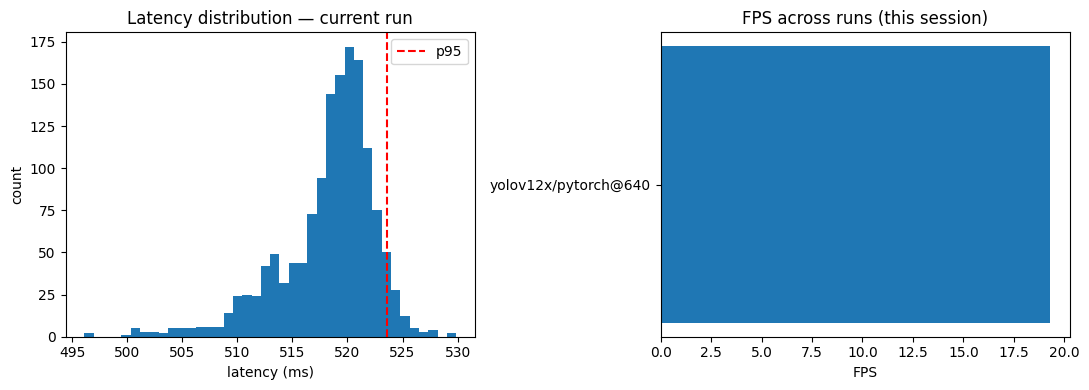

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(latencies_ms, bins=40)
axes[0].axvline(throughput["latency_p95_ms"], linestyle="--", color="red", label="p95")
axes[0].set_xlabel("latency (ms)")
axes[0].set_ylabel("count")
axes[0].set_title("Latency distribution — current run")
axes[0].legend()

labels = [f"{r.variant}/{r.backend}@{r.imgsz}" for r in results_df.itertuples()]
axes[1].barh(labels, results_df["fps"])
axes[1].set_xlabel("FPS")
axes[1].set_title("FPS across runs (this session)")

plt.tight_layout()
plt.show()